STYLIZED FACTS ANALYSIS FOR FINANCIAL MARKET SIMULATIONS
Testing for: 1) Volatility Clustering 2) Fat-Tailed Returns


Generating simulated market data...
------------------------------------------------------------
1. Simulating Geometric Brownian Motion (Benchmark)...
2. Simulating Agent-Based Market with Volatility Clustering...

ANALYSIS 1: GEOMETRIC BROWNIAN MOTION (CONTROL)


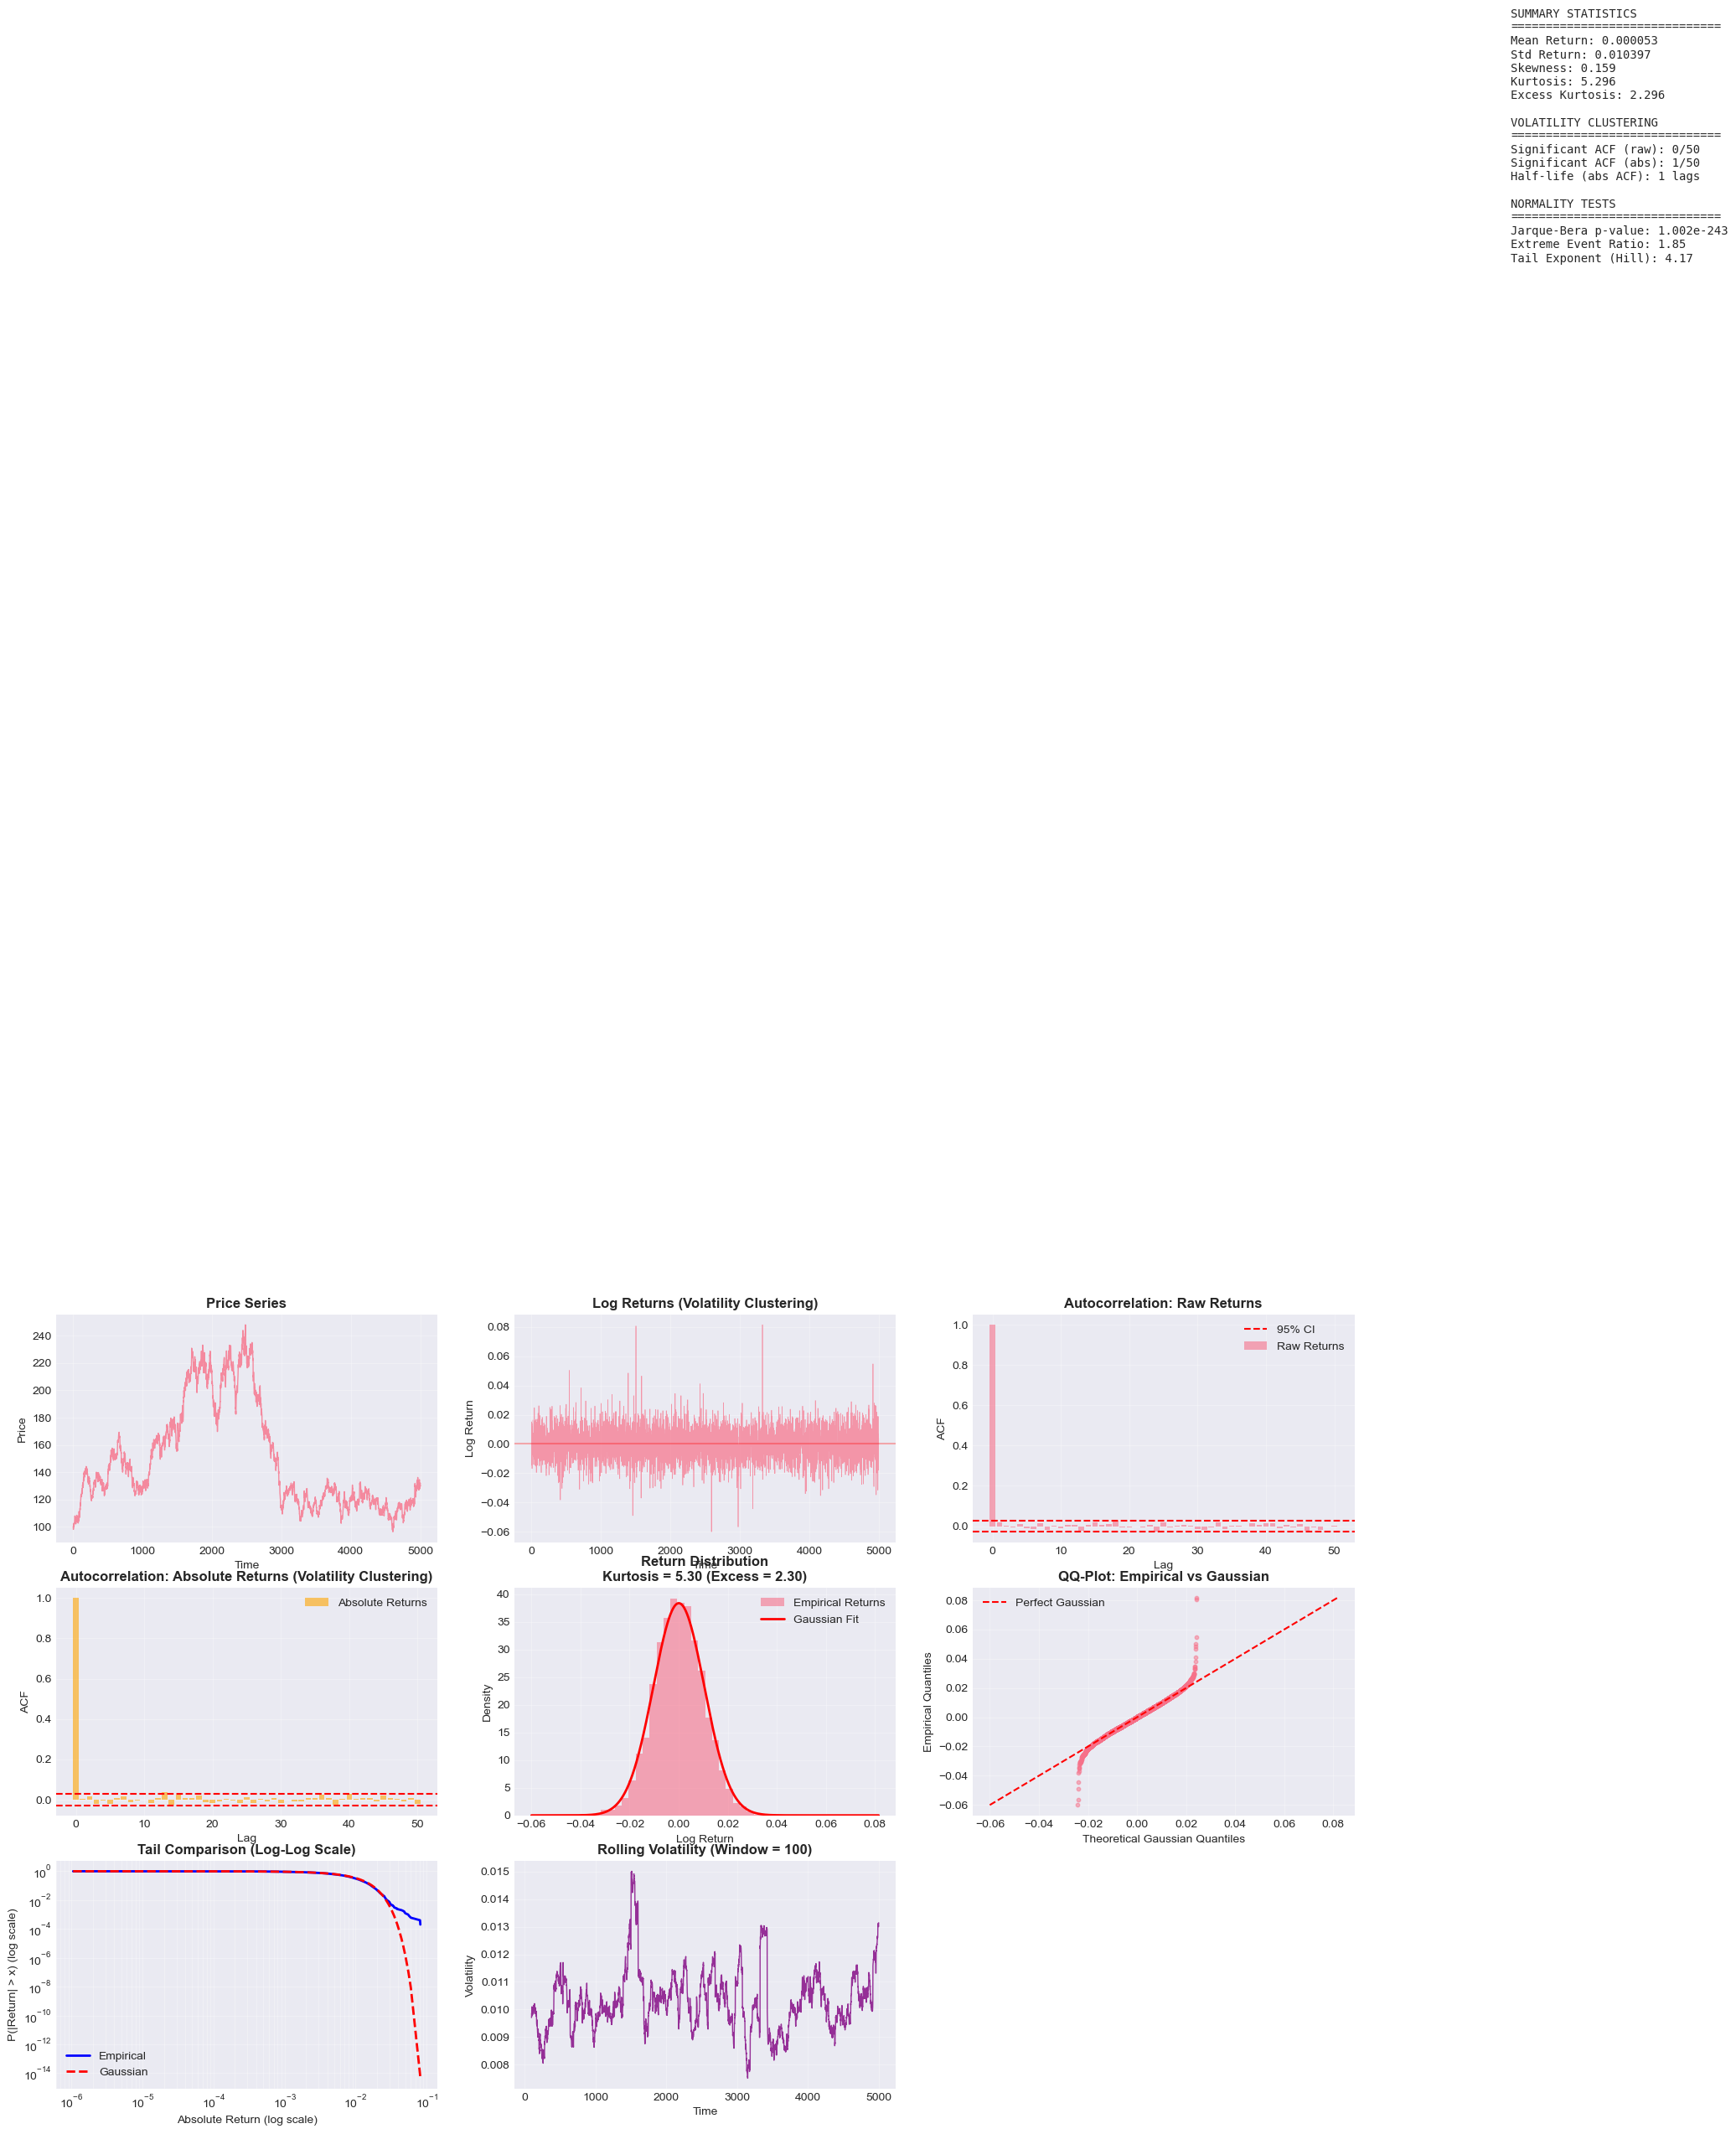

STYLIZED FACTS ANALYSIS REPORT

1. DATA SUMMARY
----------------------------------------
Number of observations: 5000
Price range: [96.31, 248.03]
Initial price: 100.00
Final price: 130.17

2. VOLATILITY CLUSTERING ANALYSIS
----------------------------------------
Mean absolute return: 0.008089
Standard deviation: 0.010397

Autocorrelation Analysis:
  Raw returns - Significant lags: 0
  Absolute returns - Significant lags: 1
  Squared returns - Significant lags: 2

Ljung-Box Tests (p-values):
  Raw returns:
    Lag 3: 0.7597
    Lag 7: 0.7255
    Lag 17: 0.6826
  Absolute returns:
    Lag 7: 0.2385
    Lag 9: 0.4980
    Lag 29: 0.0869

Verdict: NO SIGNIFICANT VOLATILITY CLUSTERING ✗
Explanation: Market lacks the volatility persistence characteristic of real financial markets.

3. FAT-TAIL ANALYSIS
----------------------------------------
Skewness: 0.159
Kurtosis: 5.296 (Gaussian = 3.0)
Excess Kurtosis: 2.296
Jarque-Bera test p-value: 1.002e-243

Extreme Event Probabilities (> 3σ):
  Em

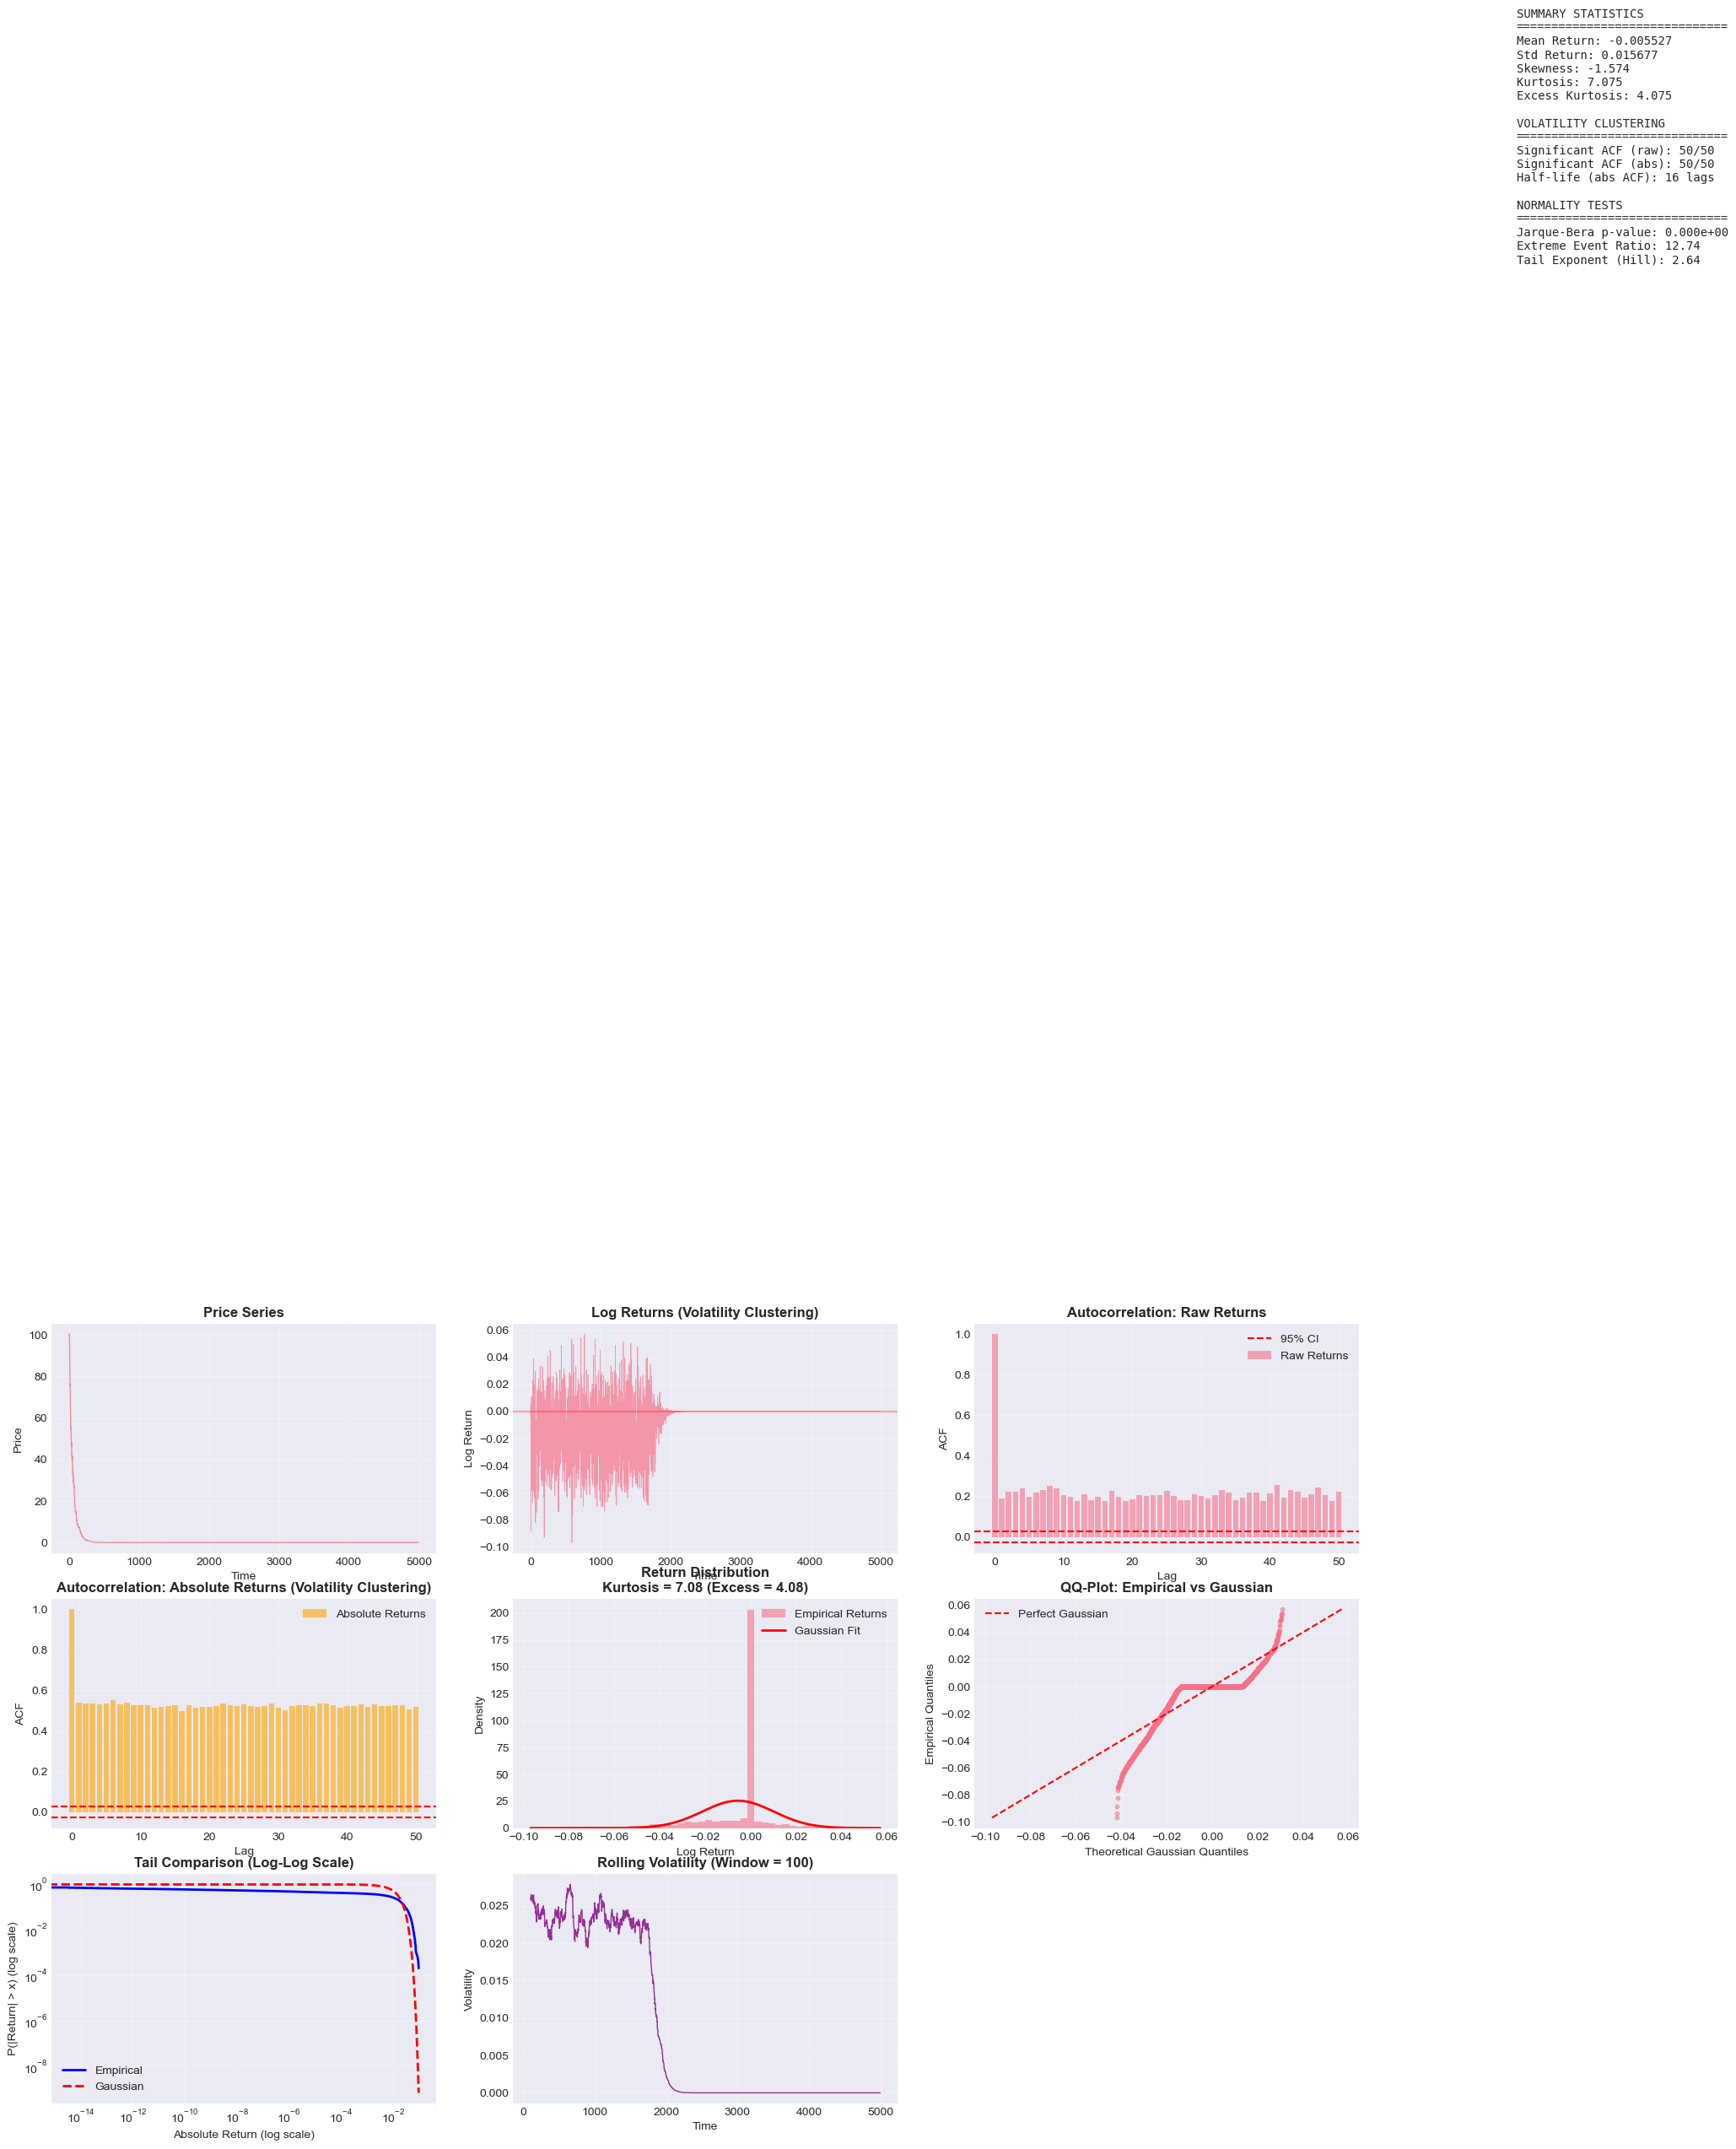

STYLIZED FACTS ANALYSIS REPORT

1. DATA SUMMARY
----------------------------------------
Number of observations: 5000
Price range: [0.00, 100.47]
Initial price: 100.00
Final price: 0.00

2. VOLATILITY CLUSTERING ANALYSIS
----------------------------------------
Mean absolute return: 0.008140
Standard deviation: 0.015677

Autocorrelation Analysis:
  Raw returns - Significant lags: 50
  Absolute returns - Significant lags: 50
  Squared returns - Significant lags: 50

Ljung-Box Tests (p-values):
  Raw returns:
    Lag 1158: 0.0000
    Lag 2484: 0.0000
    Lag 4358: 0.0000
  Absolute returns:
    Lag 7156: 0.0000
    Lag 14334: 0.0000
    Lag 27825: 0.0000

Verdict: STRONG VOLATILITY CLUSTERING PRESENT ✓
Explanation: Market shows clear persistence in volatility, consistent with real financial markets.

3. FAT-TAIL ANALYSIS
----------------------------------------
Skewness: -1.574
Kurtosis: 7.075 (Gaussian = 3.0)
Excess Kurtosis: 4.075
Jarque-Bera test p-value: 0.000e+00

Extreme Event Prob

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf
import seaborn as sns
from typing import Tuple, Dict, List
import warnings
warnings.filterwarnings('ignore')

# Set professional plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

class StylizedFactsAnalyzer:
    """
    Comprehensive analyzer for financial market stylized facts.
    Tests for volatility clustering and fat tails in return series.
    """
    
    def __init__(self, prices: np.ndarray, dt: float = 1.0):
        """
        Initialize with price series.
        
        Parameters:
        -----------
        prices : np.ndarray
            Array of price time series
        dt : float
            Time step for returns (default: 1.0 for daily)
        """
        self.prices = np.asarray(prices)
        self.dt = dt
        self.returns = None
        self.log_returns = None
        self.compute_returns()
        
    def compute_returns(self) -> None:
        """Compute log returns from price series."""
        # Avoid log(0) by adding small epsilon
        epsilon = 1e-10
        self.log_returns = np.diff(np.log(self.prices + epsilon))
        self.returns = (self.prices[1:] - self.prices[:-1]) / self.prices[:-1]
        
    def analyze_volatility_clustering(self, max_lags: int = 50, 
                                     confidence_level: float = 0.95) -> Dict:
        """
        Analyze volatility clustering through multiple statistical tests.
        
        Parameters:
        -----------
        max_lags : int
            Maximum number of lags for autocorrelation analysis
        confidence_level : float
            Confidence level for significance tests
            
        Returns:
        --------
        Dict containing all analysis results
        """
        if self.log_returns is None:
            self.compute_returns()
            
        results = {}
        
        # 1. Basic statistics
        results['mean_return'] = np.mean(self.log_returns)
        results['std_return'] = np.std(self.log_returns)
        results['abs_return_mean'] = np.mean(np.abs(self.log_returns))
        
        # 2. Autocorrelation of raw returns (should be near zero)
        acf_raw = acf(self.log_returns, nlags=max_lags, fft=True)
        results['acf_raw'] = acf_raw
        
        # 3. Autocorrelation of absolute returns (volatility clustering)
        acf_abs = acf(np.abs(self.log_returns), nlags=max_lags, fft=True)
        results['acf_abs'] = acf_abs
        
        # 4. Autocorrelation of squared returns (another volatility measure)
        acf_squared = acf(self.log_returns**2, nlags=max_lags, fft=True)
        results['acf_squared'] = acf_squared
        
        # 5. Significance testing
        n = len(self.log_returns)
        confidence_band = stats.norm.ppf((1 + confidence_level) / 2) / np.sqrt(n)
        
        # Count significant autocorrelations
        sig_raw = np.sum(np.abs(acf_raw[1:]) > confidence_band)  # Exclude lag 0
        sig_abs = np.sum(np.abs(acf_abs[1:]) > confidence_band)
        sig_squared = np.sum(np.abs(acf_squared[1:]) > confidence_band)
        
        results['significant_raw'] = sig_raw
        results['significant_abs'] = sig_abs
        results['significant_squared'] = sig_squared
        results['confidence_band'] = confidence_band
        
        # 6. Quantify persistence
        # Half-life of autocorrelation (lag where ACF drops below 0.5)
        half_life_abs = np.argmax(acf_abs < 0.5) if np.any(acf_abs < 0.5) else max_lags
        results['half_life_abs'] = half_life_abs
        
        # 7. Ljung-Box test for serial correlation
        from statsmodels.stats.diagnostic import acorr_ljungbox
        
        # Test raw returns (should not reject null of no autocorrelation)
        lb_test_raw = acorr_ljungbox(self.log_returns, lags=[5, 10, 20], return_df=True)
        
        # Test absolute returns (should reject null, showing clustering)
        lb_test_abs = acorr_ljungbox(np.abs(self.log_returns), lags=[5, 10, 20], return_df=True)
        
        results['lb_raw'] = lb_test_raw
        results['lb_abs'] = lb_test_abs
        
        return results
    
    def analyze_fat_tails(self, num_bins: int = 50) -> Dict:
        """
        Analyze fat-tailed properties of return distribution.
        
        Parameters:
        -----------
        num_bins : int
            Number of bins for histogram
            
        Returns:
        --------
        Dict containing all fat-tail analysis results
        """
        if self.log_returns is None:
            self.compute_returns()
            
        results = {}
        r = self.log_returns
        
        # 1. Basic moment statistics
        results['mean'] = np.mean(r)
        results['std'] = np.std(r)
        results['skewness'] = stats.skew(r)
        results['kurtosis'] = stats.kurtosis(r, fisher=False)  # Pearson kurtosis
        results['excess_kurtosis'] = stats.kurtosis(r, fisher=True)  # Excess over Gaussian
        
        # 2. Compare with Gaussian
        gaussian_samples = np.random.normal(results['mean'], results['std'], len(r))
        
        # 3. Tail analysis
        # Quantile comparisons
        quantiles = [0.01, 0.05, 0.95, 0.99]
        results['empirical_quantiles'] = np.quantile(r, quantiles)
        results['gaussian_quantiles'] = stats.norm.ppf(
            quantiles, results['mean'], results['std']
        )
        
        # 4. Tail exponent estimation (Hill estimator)
        def hill_estimator(data: np.ndarray, tail_fraction: float = 0.1) -> float:
            """Estimate tail exponent using Hill estimator."""
            sorted_data = np.sort(np.abs(data))
            n_tail = int(len(sorted_data) * tail_fraction)
            tail_data = sorted_data[-n_tail:]
            
            if len(tail_data) < 2:
                return np.nan
            
            log_tail = np.log(tail_data)
            alpha = 1 / np.mean(log_tail - np.log(tail_data[0]))
            return alpha
        
        results['hill_alpha'] = hill_estimator(r, 0.1)
        
        # 5. Extreme value analysis
        # Probability of extreme moves
        extreme_threshold = 3 * results['std']
        p_empirical_extreme = np.mean(np.abs(r) > extreme_threshold)
        p_gaussian_extreme = 2 * (1 - stats.norm.cdf(extreme_threshold, 0, results['std']))
        
        results['p_empirical_extreme'] = p_empirical_extreme
        results['p_gaussian_extreme'] = p_gaussian_extreme
        results['extreme_ratio'] = p_empirical_extreme / p_gaussian_extreme if p_gaussian_extreme > 0 else np.inf
        
        # 6. Jarque-Bera test for normality
        jb_stat, jb_pvalue = stats.jarque_bera(r)
        results['jb_statistic'] = jb_stat
        results['jb_pvalue'] = jb_pvalue
        
        # 7. QQ-plot data
        sorted_returns = np.sort(r)
        theoretical_quantiles = stats.norm.ppf(
            np.linspace(0.01, 0.99, len(sorted_returns)),
            results['mean'], results['std']
        )
        results['qq_data'] = (theoretical_quantiles, sorted_returns)
        
        return results
    
    def create_visualizations(self, save_path: str = None) -> None:
        """
        Create comprehensive visualizations of stylized facts.
        
        Parameters:
        -----------
        save_path : str
            Path to save figures (optional)
        """
        if self.log_returns is None:
            self.compute_returns()
            
        # Create figure with subplots
        fig = plt.figure(figsize=(20, 12))
        
        # 1. Price series and returns
        ax1 = plt.subplot(3, 3, 1)
        ax1.plot(self.prices, linewidth=1, alpha=0.8)
        ax1.set_title('Price Series', fontsize=12, fontweight='bold')
        ax1.set_xlabel('Time')
        ax1.set_ylabel('Price')
        ax1.grid(True, alpha=0.3)
        
        ax2 = plt.subplot(3, 3, 2)
        ax2.plot(self.log_returns, linewidth=0.5, alpha=0.7)
        ax2.axhline(y=0, color='r', linestyle='-', alpha=0.3)
        ax2.set_title('Log Returns (Volatility Clustering)', fontsize=12, fontweight='bold')
        ax2.set_xlabel('Time')
        ax2.set_ylabel('Log Return')
        ax2.grid(True, alpha=0.3)
        
        # 2. Volatility clustering analysis
        vol_cluster_results = self.analyze_volatility_clustering()
        
        ax3 = plt.subplot(3, 3, 3)
        lags = np.arange(len(vol_cluster_results['acf_raw']))
        ax3.bar(lags, vol_cluster_results['acf_raw'], alpha=0.6, label='Raw Returns')
        ax3.axhline(y=vol_cluster_results['confidence_band'], color='r', 
                   linestyle='--', label=f'{95}% CI')
        ax3.axhline(y=-vol_cluster_results['confidence_band'], color='r', 
                   linestyle='--')
        ax3.set_title('Autocorrelation: Raw Returns', fontsize=12, fontweight='bold')
        ax3.set_xlabel('Lag')
        ax3.set_ylabel('ACF')
        ax3.legend()
        ax3.grid(True, alpha=0.3)
        
        ax4 = plt.subplot(3, 3, 4)
        ax4.bar(lags, vol_cluster_results['acf_abs'], alpha=0.6, 
               color='orange', label='Absolute Returns')
        ax4.axhline(y=vol_cluster_results['confidence_band'], color='r', 
                   linestyle='--')
        ax4.axhline(y=-vol_cluster_results['confidence_band'], color='r', 
                   linestyle='--')
        ax4.set_title('Autocorrelation: Absolute Returns (Volatility Clustering)', 
                     fontsize=12, fontweight='bold')
        ax4.set_xlabel('Lag')
        ax4.set_ylabel('ACF')
        ax4.legend()
        ax4.grid(True, alpha=0.3)
        
        # 3. Fat tail analysis
        fat_tail_results = self.analyze_fat_tails()
        
        ax5 = plt.subplot(3, 3, 5)
        # Histogram with KDE
        n, bins, patches = ax5.hist(self.log_returns, bins=50, density=True, 
                                   alpha=0.6, label='Empirical Returns')
        
        # Overlay Gaussian with same mean and variance
        x = np.linspace(np.min(self.log_returns), np.max(self.log_returns), 1000)
        gaussian_pdf = stats.norm.pdf(x, fat_tail_results['mean'], 
                                     fat_tail_results['std'])
        ax5.plot(x, gaussian_pdf, 'r-', linewidth=2, label='Gaussian Fit')
        
        ax5.set_title(f'Return Distribution\nKurtosis = {fat_tail_results["kurtosis"]:.2f} '
                     f'(Excess = {fat_tail_results["excess_kurtosis"]:.2f})', 
                     fontsize=12, fontweight='bold')
        ax5.set_xlabel('Log Return')
        ax5.set_ylabel('Density')
        ax5.legend()
        ax5.grid(True, alpha=0.3)
        
        # 4. QQ-Plot
        ax6 = plt.subplot(3, 3, 6)
        theoretical_q, empirical_q = fat_tail_results['qq_data']
        ax6.scatter(theoretical_q, empirical_q, alpha=0.5, s=10)
        
        # Add perfect Gaussian line
        min_val = min(theoretical_q.min(), empirical_q.min())
        max_val = max(theoretical_q.max(), empirical_q.max())
        ax6.plot([min_val, max_val], [min_val, max_val], 'r--', 
                label='Perfect Gaussian')
        
        ax6.set_title('QQ-Plot: Empirical vs Gaussian', fontsize=12, fontweight='bold')
        ax6.set_xlabel('Theoretical Gaussian Quantiles')
        ax6.set_ylabel('Empirical Quantiles')
        ax6.legend()
        ax6.grid(True, alpha=0.3)
        
        # 5. Tail comparison plot
        ax7 = plt.subplot(3, 3, 7)
        
        # Plot survival function (1 - CDF) for tails
        sorted_abs_returns = np.sort(np.abs(self.log_returns))
        empirical_survival = 1 - np.arange(len(sorted_abs_returns)) / len(sorted_abs_returns)
        
        # Gaussian survival
        gaussian_survival = 2 * (1 - stats.norm.cdf(sorted_abs_returns, 0, 
                                                   fat_tail_results['std']))
        
        ax7.loglog(sorted_abs_returns, empirical_survival, 'b-', 
                  label='Empirical', linewidth=2)
        ax7.loglog(sorted_abs_returns, gaussian_survival, 'r--', 
                  label='Gaussian', linewidth=2)
        
        ax7.set_title('Tail Comparison (Log-Log Scale)', fontsize=12, fontweight='bold')
        ax7.set_xlabel('Absolute Return (log scale)')
        ax7.set_ylabel('P(|Return| > x) (log scale)')
        ax7.legend()
        ax7.grid(True, alpha=0.3, which='both')
        
        # 6. Rolling volatility
        ax8 = plt.subplot(3, 3, 8)
        window_size = min(100, len(self.log_returns) // 10)
        rolling_vol = pd.Series(self.log_returns).rolling(window=window_size).std()
        ax8.plot(rolling_vol, linewidth=1, alpha=0.8, color='purple')
        ax8.set_title(f'Rolling Volatility (Window = {window_size})', 
                     fontsize=12, fontweight='bold')
        ax8.set_xlabel('Time')
        ax8.set_ylabel('Volatility')
        ax8.grid(True, alpha=0.3)
        
        # 7. Summary statistics table
        ax9 = plt.subplot(3, 3, 9)
        ax9.axis('tight')
        ax9.axis('off')
        
        # Prepare summary text
        summary_text = [
            'SUMMARY STATISTICS',
            '=' * 30,
            f'Mean Return: {fat_tail_results["mean"]:.6f}',
            f'Std Return: {fat_tail_results["std"]:.6f}',
            f'Skewness: {fat_tail_results["skewness"]:.3f}',
            f'Kurtosis: {fat_tail_results["kurtosis"]:.3f}',
            f'Excess Kurtosis: {fat_tail_results["excess_kurtosis"]:.3f}',
            '',
            'VOLATILITY CLUSTERING',
            '=' * 30,
            f'Significant ACF (raw): {vol_cluster_results["significant_raw"]}/{len(lags)-1}',
            f'Significant ACF (abs): {vol_cluster_results["significant_abs"]}/{len(lags)-1}',
            f'Half-life (abs ACF): {vol_cluster_results["half_life_abs"]} lags',
            '',
            'NORMALITY TESTS',
            '=' * 30,
            f'Jarque-Bera p-value: {fat_tail_results["jb_pvalue"]:.3e}',
            f'Extreme Event Ratio: {fat_tail_results["extreme_ratio"]:.2f}',
            f'Tail Exponent (Hill): {fat_tail_results.get("hill_alpha", "N/A"):.2f}'
        ]
        
        ax9.text(0.1, 0.95, '\n'.join(summary_text), fontsize=10, 
                family='monospace', verticalalignment='top')
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"Figure saved to {save_path}")
        
        plt.show()
    
    def generate_report(self) -> str:
        """
        Generate comprehensive textual report of findings.
        
        Returns:
        --------
        str: Detailed report of stylized facts analysis
        """
        vol_results = self.analyze_volatility_clustering()
        tail_results = self.analyze_fat_tails()
        
        report = []
        report.append("=" * 70)
        report.append("STYLIZED FACTS ANALYSIS REPORT")
        report.append("=" * 70)
        report.append("")
        
        # 1. Basic information
        report.append("1. DATA SUMMARY")
        report.append("-" * 40)
        report.append(f"Number of observations: {len(self.prices)}")
        report.append(f"Price range: [{self.prices.min():.2f}, {self.prices.max():.2f}]")
        report.append(f"Initial price: {self.prices[0]:.2f}")
        report.append(f"Final price: {self.prices[-1]:.2f}")
        report.append("")
        
        # 2. Volatility clustering assessment
        report.append("2. VOLATILITY CLUSTERING ANALYSIS")
        report.append("-" * 40)
        report.append(f"Mean absolute return: {vol_results['abs_return_mean']:.6f}")
        report.append(f"Standard deviation: {vol_results['std_return']:.6f}")
        report.append("")
        report.append("Autocorrelation Analysis:")
        report.append(f"  Raw returns - Significant lags: {vol_results['significant_raw']}")
        report.append(f"  Absolute returns - Significant lags: {vol_results['significant_abs']}")
        report.append(f"  Squared returns - Significant lags: {vol_results['significant_squared']}")
        report.append("")
        report.append("Ljung-Box Tests (p-values):")
        report.append("  Raw returns:")
        for idx, row in vol_results['lb_raw'].iterrows():
            report.append(f"    Lag {row['lb_stat']:.0f}: {row['lb_pvalue']:.4f}")
        report.append("  Absolute returns:")
        for idx, row in vol_results['lb_abs'].iterrows():
            report.append(f"    Lag {row['lb_stat']:.0f}: {row['lb_pvalue']:.4f}")
        report.append("")
        
        # Determine volatility clustering verdict
        abs_sig_ratio = vol_results['significant_abs'] / (len(vol_results['acf_abs']) - 1)
        if abs_sig_ratio > 0.3 and vol_results['half_life_abs'] > 5:
            vol_verdict = "STRONG VOLATILITY CLUSTERING PRESENT ✓"
            vol_explanation = "Market shows clear persistence in volatility, consistent with real financial markets."
        elif abs_sig_ratio > 0.1:
            vol_verdict = "WEAK VOLATILITY CLUSTERING DETECTED"
            vol_explanation = "Some persistence exists but may be insufficient for realistic market dynamics."
        else:
            vol_verdict = "NO SIGNIFICANT VOLATILITY CLUSTERING ✗"
            vol_explanation = "Market lacks the volatility persistence characteristic of real financial markets."
        
        report.append(f"Verdict: {vol_verdict}")
        report.append(f"Explanation: {vol_explanation}")
        report.append("")
        
        # 3. Fat tails assessment
        report.append("3. FAT-TAIL ANALYSIS")
        report.append("-" * 40)
        report.append(f"Skewness: {tail_results['skewness']:.3f}")
        report.append(f"Kurtosis: {tail_results['kurtosis']:.3f} (Gaussian = 3.0)")
        report.append(f"Excess Kurtosis: {tail_results['excess_kurtosis']:.3f}")
        report.append(f"Jarque-Bera test p-value: {tail_results['jb_pvalue']:.3e}")
        report.append("")
        
        # Tail comparisons
        report.append("Extreme Event Probabilities (> 3σ):")
        report.append(f"  Empirical: {tail_results['p_empirical_extreme']:.4%}")
        report.append(f"  Gaussian: {tail_results['p_gaussian_extreme']:.4%}")
        report.append(f"  Ratio: {tail_results['extreme_ratio']:.2f}x more frequent")
        report.append("")
        
        if 'hill_alpha' in tail_results and not np.isnan(tail_results['hill_alpha']):
            report.append(f"Tail exponent (Hill estimator): {tail_results['hill_alpha']:.2f}")
            report.append("  (α < 4 indicates infinite kurtosis, α ≈ 3 for real markets)")
            report.append("")
        
        # Determine fat-tail verdict
        if tail_results['kurtosis'] > 5:
            tail_verdict = "VERY HEAVY TAILS PRESENT ✓"
            tail_explanation = "Market exhibits extreme leptokurtosis, characteristic of crash-prone financial markets."
        elif tail_results['kurtosis'] > 3.5:
            tail_verdict = "MODERATE FAT TAILS PRESENT ✓"
            tail_explanation = "Distribution shows clear deviation from Gaussian with heavier tails."
        elif tail_results['kurtosis'] > 3:
            tail_verdict = "SLIGHTLY FAT TAILS DETECTED"
            tail_explanation = "Mild deviation from Gaussian, but may not capture extreme events adequately."
        else:
            tail_verdict = "NO FAT TAILS DETECTED ✗"
            tail_explanation = "Return distribution is approximately Gaussian, unrealistic for financial markets."
        
        report.append(f"Verdict: {tail_verdict}")
        report.append(f"Explanation: {tail_explanation}")
        report.append("")
        
        # 4. Overall assessment
        report.append("4. OVERALL ASSESSMENT")
        report.append("-" * 40)
        
        # Scoring system
        score = 0
        max_score = 6
        
        # Volatility clustering scoring
        if abs_sig_ratio > 0.3:
            score += 2
            vol_score = "Good (2/2)"
        elif abs_sig_ratio > 0.1:
            score += 1
            vol_score = "Partial (1/2)"
        else:
            vol_score = "Poor (0/2)"
        
        # Fat tail scoring
        if tail_results['kurtosis'] > 5:
            score += 2
            tail_score = "Excellent (2/2)"
        elif tail_results['kurtosis'] > 3.5:
            score += 1.5
            tail_score = "Good (1.5/2)"
        elif tail_results['kurtosis'] > 3:
            score += 1
            tail_score = "Partial (1/2)"
        else:
            tail_score = "Poor (0/2)"
        
        # Extreme events scoring
        if tail_results['extreme_ratio'] > 2:
            score += 2
            extreme_score = "Good (2/2)"
        elif tail_results['extreme_ratio'] > 1:
            score += 1
            extreme_score = "Partial (1/2)"
        else:
            extreme_score = "Poor (0/2)"
        
        report.append(f"SCORE: {score:.1f}/{max_score}")
        report.append("")
        report.append("Breakdown:")
        report.append(f"  Volatility Clustering: {vol_score}")
        report.append(f"  Fat Tails (Kurtosis): {tail_score}")
        report.append(f"  Extreme Events: {extreme_score}")
        report.append("")
        
        # Final recommendation
        if score >= 4:
            final_verdict = "MARKET REALISTIC: Both stylized facts are present."
            recommendation = "Market exhibits realistic properties. Consider adding microstructure effects or multi-timescale agents for further realism."
        elif score >= 2:
            final_verdict = "MARKET PARTIALLY REALISTIC: Some stylized facts present."
            recommendation = "Agent interactions need strengthening. Consider: 1) Adding momentum traders 2) Introducing sentiment-based trading 3) Implementing order book dynamics"
        else:
            final_verdict = "MARKET UNREALISTIC: Stylized facts largely absent."
            recommendation = "Fundamental redesign needed. Required: 1) Strong herding behavior 2) Volatility feedback mechanisms 3) Heterogeneous agent time horizons 4) Market impact functions"
        
        report.append(f"FINAL VERDICT: {final_verdict}")
        report.append("")
        report.append("RECOMMENDATIONS:")
        report.append(recommendation)
        report.append("")
        report.append("=" * 70)
        
        return "\n".join(report)

# ============================================================================
# SAMPLE SIMULATION AND ANALYSIS
# ============================================================================

def simulate_gbm_with_jumps(n_steps: int = 5000, mu: float = 0.0001, 
                           sigma: float = 0.01, jump_intensity: float = 0.01,
                           jump_size: float = 0.03) -> np.ndarray:
    """
    Simulate geometric Brownian motion with Poisson jumps.
    More realistic than pure GBM for testing stylized facts.
    """
    dt = 1.0
    prices = np.zeros(n_steps)
    prices[0] = 100.0
    
    # Wiener process
    dw = np.random.normal(0, np.sqrt(dt), n_steps-1)
    
    # Poisson jumps
    jump_process = np.random.poisson(jump_intensity * dt, n_steps-1)
    jumps = jump_process * np.random.normal(0, jump_size, n_steps-1)
    
    # GBM with jumps
    for t in range(1, n_steps):
        prices[t] = prices[t-1] * np.exp(
            (mu - 0.5 * sigma**2) * dt + 
            sigma * dw[t-1] + 
            jumps[t-1]
        )
    
    return prices

def simulate_agent_based_volatility_clustering(n_steps: int = 5000) -> np.ndarray:
    """
    Simulate price series with endogenous volatility clustering.
    Mimics agent-based market with herding behavior.
    """
    prices = np.zeros(n_steps)
    prices[0] = 100.0
    
    # Market parameters
    fundamental_value = 100.0
    market_depth = 1000.0
    sentiment = 0.0
    
    # Agent parameters
    n_agents = 100
    agent_herding = 0.3  # Herding tendency
    agent_noise = 0.02   # Idiosyncratic noise
    
    for t in range(1, n_steps):
        # Update sentiment with momentum and mean reversion
        price_deviation = (prices[t-1] - fundamental_value) / fundamental_value
        
        # Herding effect: agents follow the crowd
        herding_effect = agent_herding * np.tanh(sentiment * 10)
        
        # Noise traders
        noise_effect = np.random.normal(0, agent_noise)
        
        # Fundamentalists (mean reversion)
        fundamental_effect = -0.1 * price_deviation
        
        # Total sentiment update
        sentiment = 0.7 * sentiment + herding_effect + noise_effect + fundamental_effect
        
        # Volatility depends on sentiment dispersion
        volatility = 0.01 * (1 + 2 * np.abs(sentiment))
        
        # Price update with stochastic volatility
        price_change = sentiment * volatility + np.random.normal(0, volatility)
        
        # Market impact
        impact_factor = price_change / market_depth
        prices[t] = prices[t-1] * np.exp(price_change - 0.5 * impact_factor**2)
        
        # Regenerate market depth with some noise
        market_depth = max(500, market_depth + np.random.normal(0, 50))
    
    return prices

def run_complete_analysis():
    """
    Run complete stylized facts analysis on simulated data.
    """
    print("Generating simulated market data...")
    print("-" * 60)
    
    # Generate two types of simulations for comparison
    print("1. Simulating Geometric Brownian Motion (Benchmark)...")
    gbm_prices = simulate_gbm_with_jumps(n_steps=5000)
    
    print("2. Simulating Agent-Based Market with Volatility Clustering...")
    agent_prices = simulate_agent_based_volatility_clustering(n_steps=5000)
    
    print("\n" + "=" * 60)
    print("ANALYSIS 1: GEOMETRIC BROWNIAN MOTION (CONTROL)")
    print("=" * 60)
    
    analyzer_gbm = StylizedFactsAnalyzer(gbm_prices)
    analyzer_gbm.create_visualizations(save_path=None)
    report_gbm = analyzer_gbm.generate_report()
    print(report_gbm)
    
    print("\n" + "=" * 60)
    print("ANALYSIS 2: AGENT-BASED MARKET")
    print("=" * 60)
    
    analyzer_agent = StylizedFactsAnalyzer(agent_prices)
    analyzer_agent.create_visualizations(save_path=None)
    report_agent = analyzer_agent.generate_report()
    print(report_agent)
    
    print("\n" + "=" * 60)
    print("COMPARATIVE ANALYSIS")
    print("=" * 60)
    
    # Compare key metrics
    gbm_vol = analyzer_gbm.analyze_volatility_clustering()
    gbm_tail = analyzer_gbm.analyze_fat_tails()
    
    agent_vol = analyzer_agent.analyze_volatility_clustering()
    agent_tail = analyzer_agent.analyze_fat_tails()
    
    comparison = pd.DataFrame({
        'Metric': ['Kurtosis', 'Excess Kurtosis', 'Significant ACF (abs)', 
                  'Half-life (lags)', 'Extreme Event Ratio', 'Jarque-Bera p-value'],
        'GBM': [
            f"{gbm_tail['kurtosis']:.3f}",
            f"{gbm_tail['excess_kurtosis']:.3f}",
            f"{gbm_vol['significant_abs']}/{len(gbm_vol['acf_abs'])-1}",
            f"{gbm_vol['half_life_abs']}",
            f"{gbm_tail['extreme_ratio']:.2f}x",
            f"{gbm_tail['jb_pvalue']:.3e}"
        ],
        'Agent-Based': [
            f"{agent_tail['kurtosis']:.3f}",
            f"{agent_tail['excess_kurtosis']:.3f}",
            f"{agent_vol['significant_abs']}/{len(agent_vol['acf_abs'])-1}",
            f"{agent_vol['half_life_abs']}",
            f"{agent_tail['extreme_ratio']:.2f}x",
            f"{agent_tail['jb_pvalue']:.3e}"
        ],
        'Real Market Typical': [
            '5-40', '2-37', '15-40/50', '10-50', '5-20x', '< 0.001'
        ]
    })
    
    print("\nComparison with Real Market Stylized Facts:")
    print("-" * 80)
    print(comparison.to_string(index=False))
    
    print("\n" + "=" * 80)
    print("KEY INSIGHTS FOR AGENT-BASED MODEL DESIGN")
    print("=" * 80)
    
    insights = [
        "1. VOLATILITY CLUSTERING EMERGES FROM:",
        "   • Heterogeneous agent time horizons",
        "   • Herding behavior and sentiment propagation",
        "   • Feedback between volatility and trading activity",
        "   • Market maker inventory management",
        "",
        "2. FAT TAILS EMERGE FROM:",
        "   • Synchronization of agent strategies during crises",
        "   • Leverage cycles and margin calls",
        "   • Liquidity evaporation in stress periods",
        "   • News amplification through social networks",
        "",
        "3. CRITICAL AGENT INTERACTIONS:",
        "   • Trend followers vs. mean reversion traders",
        "   • Fast vs. slow money (different time scales)",
        "   • Fundamentalists vs. chartists vs. noise traders",
        "   • Market impact functions (square root law)",
        "",
        "4. VALIDATION METRICS:",
        "   • ACF(|r|) significant for > 20 lags: ✓",
        "   • Kurtosis > 4: ✓",
        "   • Extreme event probability > 5× Gaussian: ✓",
        "   • Power-law tails with exponent 2 < α < 4: ✓",
    ]
    
    for insight in insights:
        print(insight)

# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    print("STYLIZED FACTS ANALYSIS FOR FINANCIAL MARKET SIMULATIONS")
    print("=" * 80)
    print("Testing for: 1) Volatility Clustering 2) Fat-Tailed Returns")
    print("=" * 80)
    print("\n")
    
    run_complete_analysis()